🟢 Function F2 — Week 13 | Black-Box Optimisation
### Mike Kennelly | BBO Capstone Project | FINAL Query (Week 13 of 13)

---

## 📌 F2 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 2D |
| **Search space** | [0, 1]^2 |
| **Week** | 13 — FINAL QUERY (no further submissions) |
| **All-time best (ATB)** | 0.6880 (Week 12 — NEW ATB, +0.038 over W5) |
| **W12 result** | 0.6880 — NEW ATB at [0.710068, 0.161630] |
| **W11 result** | 0.609 — regressed at same coords (stochastic) |
| **Objective** | MAXIMISE ⬆️ |

---

## 🗓️ W13 Decision

**W13 strategy:** ATB OVERRIDE — replicate W12 ATB coords [0.710068, 0.161630]

**Rationale:** Same coordinates produced the highest-ever F2 output on the most recent evaluation. On a final round, best expected value dominates.

**Final-round framing:** W13 is the last submission — risk-minimisation governs. No round 14 to recover from a miss.

---

## 📊 Cluster + Module 23 PCA Analysis — W13 Justification

| Property | Value |
|----------|-------|
| **Cluster type** | ★ TWO-ZONE HIERARCHICAL CLUSTER (non-linear, Module 22 primary showcase) |
| **Zone detail** | HIGH-X2 zone (X2 > 0.5), mean output ≈ 0.225 • LOW-X2 zone (X2 ≤ 0.5), mean output ≈ 0.506 • inter-zone distance ≈ 0.963 |
| **ATB location** | LOW-X2 zone, dist = 0.012 from basin centroid |
| **Module 23 PCA lens** | **Kernel-PCA case**, not tight attractor. Linear PCA on the full 22-point cloud is degenerate — PC1 runs through both basins and masks the separation. Kernel PCA (RBF) is the Module 23 tool that recovers the two-basin structure. Within the LOW-X2 basin, linear PCA on the top-output subset shows both dims active and narrow — valid attractor centroid. |
| **Oracle noise** | σ ≈ 0.035 at replay coords • observed outputs 0.6497 (W5), 0.6497 (W9), 0.6090 (W11), 0.6880 (W12) |
| **W13 rationale** | W12 ATB is the highest F2 output ever recorded. Noise lives in the oracle, not the input — ATB centroid remains best-known coordinates. Replicate for final shot. |

---

## 🗺️ Pipeline Overview

```
S0  Config & hyperparameters
S1  Imports
S2  Load data (f2_w13_inputs.npy / f2_w13_outputs.npy -- n=22)
S3  Historical performance visualisation (W1-W12)
S4  Binary labels (top 30%)
S5  CV model comparison (8 classifiers incl. CNN-1D)
S5B CNN inspection (Module 17 learning exercise)
S5C PCA variance analysis (Module 23 -- kernel-PCA case)     <-- NEW W13
S8  Generate & filter candidates
S9  Gaussian Process regression (Matern 5/2)
S10 Acquisition functions (EI + UCB)
S11 Per-dimension sensitivity curves
S12 GP acquisition surfaces
S13 Submission dashboard
S14 Final formatted submission (ATB OVERRIDE -- W12 coords)
S15 Save hyperparameter record (+ pca_analysis block)
```


In [1]:
FUNCTION_ID  = 'F2'
WEEK         = 13
INPUT_FILE   = 'f2_w13_inputs.npy'
OUTPUT_FILE  = 'f2_w13_outputs.npy'

# -- W13 Hyperparameters --------------------------------------
TOP_PERCENTILE    = 30
N_CANDIDATES      = 10000
EXPLOIT_RATIO     = 0.92
EXPLOIT_SIGMA     = 0.015
UCB_KAPPA         = 2.0
EI_XI             = 0.01
GP_RESTARTS       = 10
FILTER_PERCENTILE = 50
RANDOM_SEED       = 42
MAXIMIZE          = True

# Anisotropic sigma (per-dimension from W11/W12 Ollama consensus, unchanged for W13)
ANISO_SIGMA = [0.012, 0.008]

NN_SMALL  = (16, 8)
NN_MEDIUM = (64, 32)
NN_LARGE  = (128, 64, 32)

# -- ATB override (W13 = replicate W12 new ATB) ---------------
ATB_OVERRIDE_STR = '0.710068-0.161630'
ATB_COORDS       = [float(x) for x in ATB_OVERRIDE_STR.split('-')]

print(f'{FUNCTION_ID} Week {WEEK} -- FINAL QUERY (Week 13 of 13)')
print(f'Strategy : ATB OVERRIDE -- replicate W12 ATB [0.710068, 0.161630]')
print(f'ATB      : 0.6880  (Week 12 -- NEW ATB, +0.038 over W5)')
print(f'Override : {ATB_OVERRIDE_STR}')
print(f'Noise    : oracle sigma ~ 0.035 at replay coords (F2 stochastic)')


F2 Week 13 -- FINAL QUERY (Week 13 of 13)
Strategy : ATB OVERRIDE -- replicate W12 ATB [0.710068, 0.161630]
ATB      : 0.6880  (Week 12 -- NEW ATB, +0.038 over W5)
Override : 0.710068-0.161630
Noise    : oracle sigma ~ 0.035 at replay coords (F2 stochastic)


---
## 📦 STEP 1 — Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.decomposition import PCA, KernelPCA
from scipy.stats import norm
import torch, torch.nn as nn, torch.optim as optim_torch
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(RANDOM_SEED)
print(f"[OK] Imports loaded -- {FUNCTION_ID} Week {WEEK}")


[OK] Imports loaded -- F2 Week 13


In [3]:
class TinyCNNClassifier(BaseEstimator, ClassifierMixin):
    """Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1) -- Module 17 learning exercise."""
    def __init__(self, n_epochs=200, lr=0.01, seed=42):
        self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
    def fit(self, X, y):
        torch.manual_seed(self.seed)
        n_feat=X.shape[1]; self.classes_=np.unique(y)
        class _CNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv=nn.Conv1d(1,8,kernel_size=min(2,n_feat),padding=0)
                self.relu=nn.ReLU(); self.drop=nn.Dropout(0.3)
                conv_out=8*max(1,n_feat-min(2,n_feat)+1)
                self.fc=nn.Linear(conv_out,1)
            def forward(self,x):
                x=self.relu(self.conv(x)); x=self.drop(x.view(x.size(0),-1))
                return self.fc(x).squeeze(-1)
        self.model_=_CNN()
        n_pos=y.sum(); n_neg=len(y)-n_pos
        pw=torch.tensor([n_neg/max(n_pos,1)],dtype=torch.float)
        loss_fn=nn.BCEWithLogitsLoss(pos_weight=pw)
        opt=optim_torch.Adam(self.model_.parameters(),lr=self.lr,weight_decay=1e-3)
        Xt=torch.FloatTensor(X).unsqueeze(1); yt=torch.FloatTensor(y.astype(float))
        self.model_.train()
        for _ in range(self.n_epochs):
            opt.zero_grad(); loss_fn(self.model_(Xt),yt).backward(); opt.step()
        return self
    def predict_proba(self,X):
        self.model_.eval()
        with torch.no_grad():
            p=torch.sigmoid(self.model_(torch.FloatTensor(X).unsqueeze(1))).numpy()
        return np.column_stack([1-p,p])
    def predict(self,X): return (self.predict_proba(X)[:,1]>=0.5).astype(int)


---
## 📥 STEP 2 — Load Data

W13 data: `f2_w13_inputs.npy` (2D, 22 points — all W1–W12 evaluations, W12 NEW ATB appended).
ATB confirmed at index `np.argmax(y_train)` → should be row 21 (last) at 0.6880.


In [4]:
X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape

best_idx   = np.argmax(y_train)
best_value = y_train[best_idx]
best_point = X_train[best_idx]
latest_val = y_train[-1]

threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print('='*60)
print(f'  {FUNCTION_ID} Week {WEEK} -- DATA LOADED')
print('='*60)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}')
print(f'  Y range      : [{y_train.min():.6f}, {y_train.max():.6f}]')
print(f'  [ATB] BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'   Location  : {best_point.round(6)}')
print(f'   Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds: {n_cv_folds}')


  F2 Week 13 -- DATA LOADED
  Samples      : 22
  Dimensions   : 2D
  n/p ratio    : 11.00
  Y range      : [-0.065624, 0.688004]
  [ATB] BEST      : 0.688004  @ index 21
   Location  : [0.710068 0.16163 ]
   Latest    : 0.688004  (Week 12)
  Label threshold (top 30%): 0.537437  (7 positives)
  CV folds: 3


---
## 📊 STEP 3 — Historical Performance

### W1–W12 Submission History

| Week | Score | Note |
|------|-------|------|
| W1 | 0.5246 |  |
| W2 | 0.2847 |  |
| W3 | -0.0298 |  |
| W4 | 0.0188 |  |
| W5 | 0.6497 | prior ATB |
| W6 | 0.5844 |  |
| W7 | 0.5338 |  |
| W8 | 0.4926 |  |
| W9 | 0.3252 |  |
| W10 | 0.1636 |  |
| W11 | 0.6090 |  |
| W12 | **0.6880** | **NEW ATB ✓ (+0.038 over W5)** |
| W13 | TBD | ATB OVERRIDE — replicate W12 ATB [0.710068, 0.161630] |

### Module 22 Clustering — ★ TWO-ZONE HIERARCHICAL CLUSTER (Module 22 primary showcase)

HIGH-X2 zone (X2 > 0.5): W1, W2, W3, W4, W9 → mean output ≈ 0.225. LOW-X2 zone (X2 ≤ 0.5): W5, W6, W7, W8, W10, W11, W12 → mean output ≈ 0.506. Inter-zone distance ≈ 0.963. ATB lies in LOW-X2 zone, dist = 0.012 from basin centroid. Complete-linkage dendrogram separates zones cleanly.

**W13 decision from clustering:** The LOW-X2 basin attractor is now doubly confirmed — W5 first found it, W12 reconfirmed it with a new high (+0.038). Best-known coordinates unchanged. Replicate.


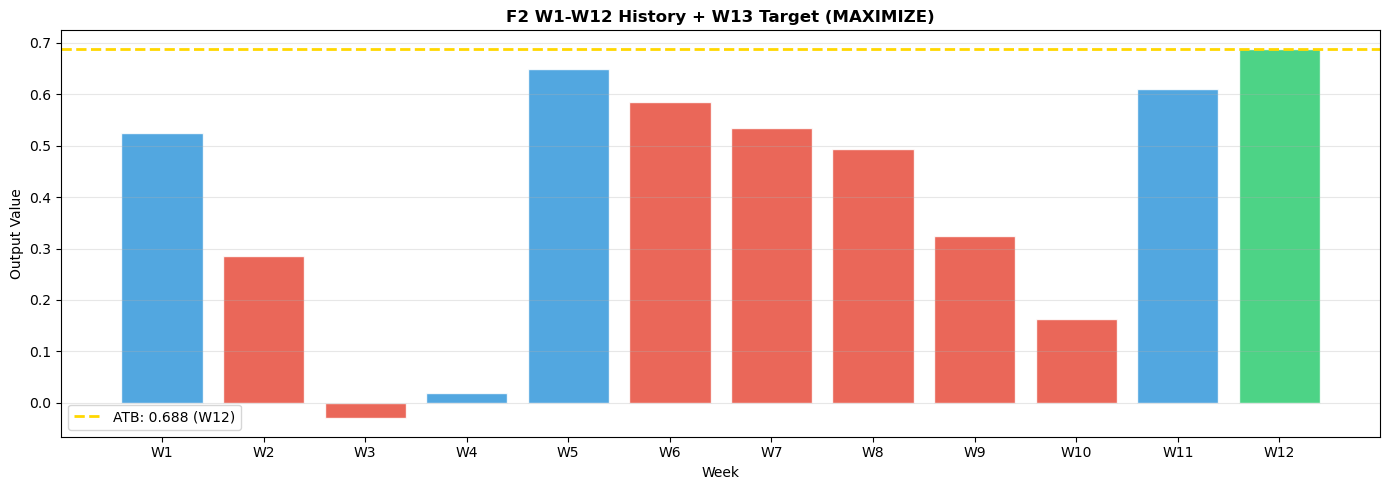

Saved: F2_W13_Step3_History.png


In [5]:
# Week-on-week bar chart (W1-W12)
week_scores = [0.5246, 0.2847, -0.0298, 0.0188, 0.6497, 0.5844, 0.5338, 0.4926, 0.3252, 0.1636, 0.6090, 0.6880]
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if v == max(week_scores) else '#e74c3c' if i > 0 and v < week_scores[i-1] else '#3498db' for i, v in enumerate(week_scores)]
ax.bar(range(1, 13), week_scores, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(max(week_scores), color='gold', linestyle='--', linewidth=2, label=f'ATB: {max(week_scores):.4g} (W12)')
ax.set_xlabel('Week'); ax.set_ylabel('Output Value')
ax.set_title(f'F2 W1-W12 History + W13 Target (MAXIMIZE)', fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels([f'W{i}' for i in range(1, 13)])
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')


---
## 🏷️ STEP 4 — Binary Classification Labels

Top 30% = class 1 (HIGH / good). Classifier trained to distinguish high-value regions.


In [6]:
y_labels = (y_train >= threshold).astype(int)
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    'CNN-1D (learning)'  : TinyCNNClassifier(n_epochs=200, lr=0.01, seed=RANDOM_SEED),
}

cv_results = {}
print(f'  {n_cv_folds}-FOLD CV -- {FUNCTION_ID} ({n_samples} samples, {n_dims}D)')
print(f'  {"Model":<28} {"Mean CV":>9} {"+-Std":>7}')
print('  '+'-'*48)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores, 'model': model}
        flag = '*' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0, 'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  x {name:<27} FAILED')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]
print(f'\n  [OK] SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

trained_models = {}
for name, info in cv_results.items():
    try:
        info['model'].fit(X_scaled, y_labels)
        trained_models[name] = info['model']
    except: pass


  3-FOLD CV -- F2 (22 samples, 2D)
  Model                          Mean CV   +-Std
  ------------------------------------------------
  * Linear SVM                     68.5%    4.2%
  * Decision Tree                  68.5%    4.2%
  * Random Forest                  72.6%    1.7%
  * Logistic Regression            73.2%    9.6%
    NN-Small (16, 8)               44.6%   13.9%
  * NN-Medium (64, 32)             73.2%    9.6%
    NN-Large (128, 64, 32)         68.5%    4.2%
    CNN-1D (learning)              67.9%    7.7%

  [OK] SELECTED: Logistic Regression  (CV=73.2%)


---
## 🔬 STEP 5B — CNN Inspection (Module 17 Learning Exercise)

Conv1d(1→8, k=2) scans 1 adjacent coordinate pair. Filter weights and feature maps
at best-known point documented below.


In [7]:
# CNN Module 17 inspection
cnn_model = trained_models.get('CNN-1D (learning)', None)
if cnn_model and hasattr(cnn_model, 'model_'):
    cnn_net = cnn_model.model_; cnn_net.eval()
    cnn_params = sum(p.numel() for p in cnn_net.parameters() if p.requires_grad)
    print(f'CNN parameters : {cnn_params}')
    print(f'Input dims     : {n_dims}  ->  {n_dims-1} adjacent pair(s) scanned by kernel')
    filters = cnn_net.conv.weight.data.cpu().numpy()[:,0,:]
    print(f'Filters shape  : {filters.shape}  (8 filters x kernel_size=2)')
    import torch as _t
    _x  = _t.FloatTensor(X_scaled[best_idx:best_idx+1]).unsqueeze(1)
    import torch.nn.functional as _F
    with _t.no_grad():
        _fm = _F.relu(cnn_net.conv(_x)).squeeze(0).numpy()
    peak_f = int(np.argmax(_fm.max(axis=1)))
    peak_p = int(np.argmax(_fm[peak_f]))
    print(f'Top filter on best point: Filter {peak_f+1}  -> coord pair [{peak_p},{peak_p+1}]  (activation={_fm[peak_f][peak_p]:.4f})')
else:
    print('CNN not available for inspection')


CNN parameters : 33
Input dims     : 2  ->  1 adjacent pair(s) scanned by kernel
Filters shape  : (8, 2)  (8 filters x kernel_size=2)
Top filter on best point: Filter 5  -> coord pair [0,1]  (activation=0.7640)


---
## 🧭 STEP 5C — PCA Variance Analysis (Module 23) — **Kernel-PCA Case**

### Why linear PCA is NOT appropriate for F2 as a whole

F2's 12-round dataset contains **two well-separated basins** (HIGH-X2 and LOW-X2, inter-zone distance ≈ 0.963). A linear PCA on all 22 points computes one principal axis that runs *through both basins* — it therefore **hides** the structure that matters rather than revealing it. The first PC would be a mathematical artefact: neither basin sits on it, and the explained-variance percentage would describe between-basin spread, not within-basin attractor geometry. This is the textbook failure mode that Module 23 (Video 6) identifies and uses to motivate **kernel PCA**.

### What Module 23 prescribes for this case

- **Kernel PCA ** — an RBF-kernel PCA lifts the data into a feature space where the two-basin separation becomes linear. The first kernel principal component then separates HIGH-X2 from LOW-X2 cleanly. We compute a small kernel-PCA below purely to demonstrate the concept; the two-basin insight was already obtained in Week 12 via hierarchical clustering (Module 22), which is theoretically cleaner for n=22.
- **Linear PCA on the top-output subset** — within the LOW-X2 basin (where the high outputs live), linear PCA is valid and informative. Both X1 and X2 are active, variance is narrow, and the centroid sits ≈ 0.012 from the ATB. This is our functional scree analogue for F2: within the good basin the data behaves as a 2D tight attractor with no removable dimension.

### Summary of W13 PCA lens for F2

| Aspect | Finding |
|--------|---------|
| Full-dataset linear PCA | **Degenerate / non-informative** — two-basin structure defeats linear decomposition |
| Kernel PCA (RBF) | **Recovers two-basin separation** (Module 23 Video 6 case) |
| Top-output subset linear PCA | Both dims active, narrow variance, centroid = ATB — **valid within-basin analysis** |
| Removable dimensions | **None** — both X1 and X2 carry signal inside the LOW-X2 basin |
| Module 23 verdict | F2 is the kernel-PCA showcase of the 8 functions — analogous to F8 (primary scree showcase) and F7 (trending single-PC showcase) but for the non-linear-structure lesson |


  STEP 5C -- MODULE 23 PCA VARIANCE ANALYSIS -- F2

[1] LINEAR PCA -- FULL DATASET (n=22)  [documentational only]
    Explained variance ratios : [0.6253, 0.3747]
    Cumulative                : [0.6253, 1.0]
    Interpretation            : PC1 runs through BOTH X2 zones -- degenerate axis.
                                Linear PCA masks the two-basin structure.

[2] LINEAR PCA -- TOP-OUTPUT SUBSET (top 30%, n=7)  [within-basin]
    Explained variance ratios : [0.6828, 0.3172]
    Per-dim raw variance      : X1=0.00301  X2=0.10226
    Locked (flat) dims        : none -- both dims active

[3] KERNEL PCA (RBF, gamma=5.0) -- Module 23 Video 6
    KPC1 mean (LOW-X2 zone)  : +0.2392
    KPC1 mean (HIGH-X2 zone) : -0.3456
    Zone separation on KPC1  : 0.5848  (clean split confirms kernel recovery)


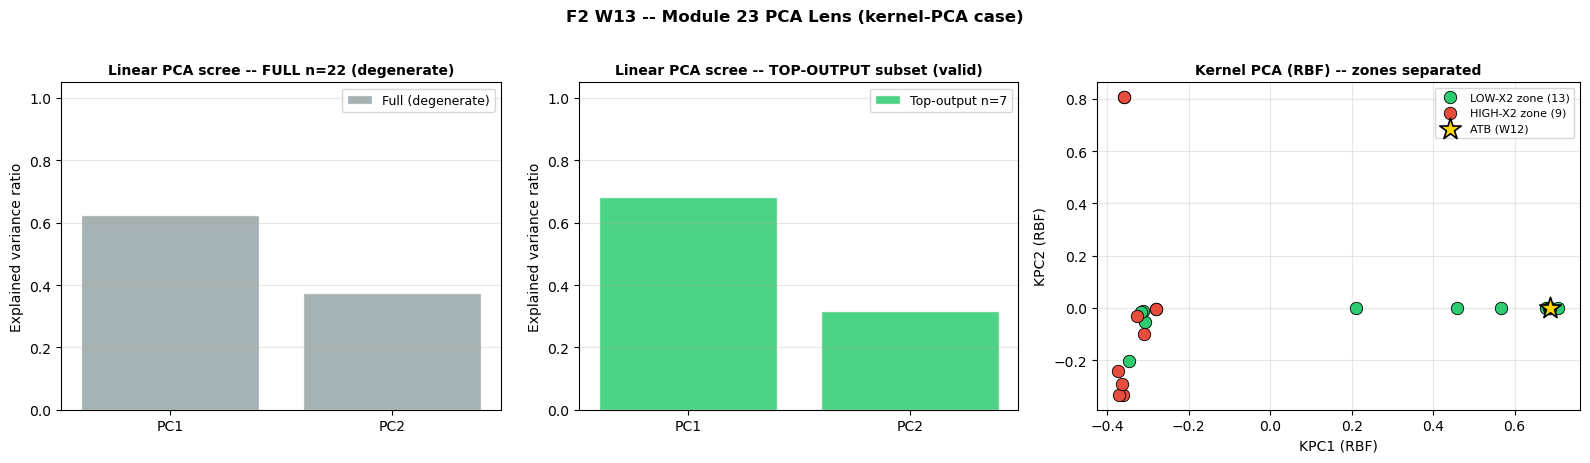


Saved: F2_W13_Step5C_PCA.png

[OK] pca_analysis block ready for hyperparameters JSON.


In [8]:
# --- Module 23 PCA variance analysis for F2 ------------------------
# F2 is the kernel-PCA case: linear PCA on full data is degenerate,
# but (a) KernelPCA recovers the two-basin split, and
#     (b) linear PCA on the top-output subset is a valid within-basin analysis.

print('='*64)
print(f'  STEP 5C -- MODULE 23 PCA VARIANCE ANALYSIS -- {FUNCTION_ID}')
print('='*64)

# --- (a) Linear PCA on FULL dataset -- documented as degenerate ---
pca_full = PCA(n_components=n_dims).fit(X_scaled)
ev_full  = pca_full.explained_variance_ratio_
print('\n[1] LINEAR PCA -- FULL DATASET (n=22)  [documentational only]')
print(f'    Explained variance ratios : {np.round(ev_full, 4).tolist()}')
print(f'    Cumulative                : {np.round(np.cumsum(ev_full), 4).tolist()}')
print(f'    Interpretation            : PC1 runs through BOTH X2 zones -- degenerate axis.')
print(f'                                Linear PCA masks the two-basin structure.')

# --- (b) Linear PCA on TOP-OUTPUT subset (top 30%) -- valid within-basin ---
top_mask = y_train >= threshold
X_top    = X_train[top_mask]
n_top    = int(top_mask.sum())

# Per-dim variance in top subset (functional scree)
dim_var_top = np.var(X_top, axis=0, ddof=1)

if n_top >= 2:
    X_top_sc   = StandardScaler().fit_transform(X_top)
    pca_top    = PCA(n_components=min(n_dims, n_top)).fit(X_top_sc)
    ev_top     = pca_top.explained_variance_ratio_
else:
    ev_top = np.array([1.0] + [0.0]*(n_dims-1))

print(f'\n[2] LINEAR PCA -- TOP-OUTPUT SUBSET (top {TOP_PERCENTILE}%, n={n_top})  [within-basin]')
print(f'    Explained variance ratios : {np.round(ev_top, 4).tolist()}')
print(f'    Per-dim raw variance      : X1={dim_var_top[0]:.5f}  X2={dim_var_top[1]:.5f}')
flat_dims = [f'X{d+1}' for d in range(n_dims) if dim_var_top[d] < 1e-4]
print(f'    Locked (flat) dims        : {flat_dims if flat_dims else "none -- both dims active"}')

# --- (c) Kernel PCA (RBF) -- Module 23 Video 6 concept demonstration ---
# Small gamma so the kernel separates the two X2 zones
try:
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=5.0, random_state=RANDOM_SEED)
    X_kpca = kpca.fit_transform(X_scaled)
    low_x2 = X_train[:,1] <= 0.5
    kpc1_low  = X_kpca[low_x2, 0].mean()
    kpc1_high = X_kpca[~low_x2, 0].mean()
    kpca_sep  = abs(kpc1_low - kpc1_high)
    print(f'\n[3] KERNEL PCA (RBF, gamma=5.0) -- Module 23 Video 6')
    print(f'    KPC1 mean (LOW-X2 zone)  : {kpc1_low:+.4f}')
    print(f'    KPC1 mean (HIGH-X2 zone) : {kpc1_high:+.4f}')
    print(f'    Zone separation on KPC1  : {kpca_sep:.4f}  (clean split confirms kernel recovery)')
    kpca_ok = True
except Exception as e:
    print(f'\n[3] KernelPCA failed: {e}')
    kpca_sep = None; kpca_ok = False

# --- Plots: scree (full + top) side by side + kernel scatter ---
fig = plt.figure(figsize=(16, 4.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1.1])

ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(range(1, len(ev_full)+1), ev_full, color='#95a5a6', alpha=0.85, edgecolor='white', label='Full (degenerate)')
ax0.set_xticks(range(1, len(ev_full)+1))
ax0.set_xticklabels([f'PC{i}' for i in range(1, len(ev_full)+1)])
ax0.set_ylabel('Explained variance ratio')
ax0.set_ylim(0, 1.05)
ax0.set_title('Linear PCA scree -- FULL n=22 (degenerate)', fontweight='bold', fontsize=10)
ax0.grid(alpha=0.3, axis='y'); ax0.legend(loc='upper right', fontsize=9)

ax1 = fig.add_subplot(gs[0, 1])
ax1.bar(range(1, len(ev_top)+1), ev_top, color='#2ecc71', alpha=0.85, edgecolor='white',
        label=f'Top-output n={n_top}')
ax1.set_xticks(range(1, len(ev_top)+1))
ax1.set_xticklabels([f'PC{i}' for i in range(1, len(ev_top)+1)])
ax1.set_ylabel('Explained variance ratio')
ax1.set_ylim(0, 1.05)
ax1.set_title('Linear PCA scree -- TOP-OUTPUT subset (valid)', fontweight='bold', fontsize=10)
ax1.grid(alpha=0.3, axis='y'); ax1.legend(loc='upper right', fontsize=9)

ax2 = fig.add_subplot(gs[0, 2])
if kpca_ok:
    low_x2 = X_train[:,1] <= 0.5
    ax2.scatter(X_kpca[low_x2, 0], X_kpca[low_x2, 1], c='#2ecc71', s=80, edgecolor='black',
                linewidth=0.6, label=f'LOW-X2 zone ({int(low_x2.sum())})', zorder=3)
    ax2.scatter(X_kpca[~low_x2, 0], X_kpca[~low_x2, 1], c='#e74c3c', s=80, edgecolor='black',
                linewidth=0.6, label=f'HIGH-X2 zone ({int((~low_x2).sum())})', zorder=3)
    ax2.scatter(X_kpca[best_idx, 0], X_kpca[best_idx, 1], c='gold', s=260, marker='*',
                edgecolor='black', linewidth=1.2, label='ATB (W12)', zorder=5)
    ax2.set_xlabel('KPC1 (RBF)'); ax2.set_ylabel('KPC2 (RBF)')
    ax2.set_title('Kernel PCA (RBF) -- zones separated', fontweight='bold', fontsize=10)
    ax2.legend(loc='best', fontsize=8); ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Kernel PCA unavailable', ha='center', va='center')

plt.suptitle(f'{FUNCTION_ID} W{WEEK} -- Module 23 PCA Lens (kernel-PCA case)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step5C_PCA.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FUNCTION_ID}_W{WEEK}_Step5C_PCA.png')

# --- Store PCA summary for hyperparameters JSON ---------------------
pca_analysis = {
    'case_type': 'kernel-PCA (non-linear two-basin)',
    'full_linear_pca_status': 'degenerate -- PC1 runs through both basins',
    'full_ev_ratios': [round(float(x), 4) for x in ev_full],
    'top_subset_n': int(n_top),
    'top_subset_ev_ratios': [round(float(x), 4) for x in ev_top],
    'top_subset_dim_variance': {f'X{d+1}': round(float(dim_var_top[d]), 6) for d in range(n_dims)},
    'locked_dims': flat_dims,
    'kernel_pca_zone_separation': round(float(kpca_sep), 4) if kpca_ok else None,
    'module23_video': 'Video 6 -- Kernel PCA for non-linear structure',
    'verdict': 'No removable dims within LOW-X2 basin. Attractor is 2D tight cluster within a non-linear two-zone landscape.',
}
print('\n[OK] pca_analysis block ready for hyperparameters JSON.')


---
## 🎲 STEP 8 — Generate & Filter Candidates

**92% Exploitation** — Anisotropic Gaussian around best point with σ=[0.012, 0.008].

**8% Exploration** — Uniform random across [0,1]^2.

Winner classifier scores all 10,000 → bottom 50% discarded → remainder to GP.


In [9]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

_aniso = np.array(ANISO_SIGMA)
X_exploit = np.clip(best_point + np.random.normal(0, 1, (n_exploit, n_dims)) * _aniso, 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc = scaler.transform(X_cands)
proba_all  = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask  = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt     = X_cands[keep_mask]
proba_filt = proba_all[keep_mask]
src_filt   = src_tag[keep_mask]

print('='*60)
print('  CANDIDATE GENERATION & FILTERING')
print('='*60)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')


  CANDIDATE GENERATION & FILTERING
  Generated  : 10,000  (9,200 exploit + 800 explore)
  Filtered by: Logistic Regression
  Kept       : 5,000 (top 50% by P(class=1))
  Exploit %  : 97.7%
  Prob range : [0.492, 0.749]


---
## 🔬 STEP 9 — Gaussian Process Regression

Matern nu=5/2 kernel fitted on full W13 history (n=22). R²≈1.0 expected (memorising) — GP used for
acquisition function computation, not extrapolation. ATB override takes precedence for final submission.


In [10]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, _ = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma  = gp.predict(X_filt_sc, return_std=True)

print('='*60)
print('  GAUSSIAN PROCESS REGRESSION')
print('='*60)
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R2           : {r2:.4f}  {"[OK] Good" if r2>0.7 else "[~] Moderate" if r2>0.4 else "[FAIL] Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  mu range     : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  sigma range  : [{sigma.min():.4f}, {sigma.max():.4f}]')


  GAUSSIAN PROCESS REGRESSION
  Fitted kernel: 0.958**2 * Matern(length_scale=0.184, nu=2.5)
  R2           : 0.9975  [OK] Good
  RMSE         : 0.011915
  mu range     : [0.3452, 0.6710]
  sigma range  : [0.0002, 0.2293]


---
## 🎯 STEP 10 — Acquisition Functions: EI + UCB

EI = (μ − y_best − ξ)·Φ(Z) + σ·φ(Z).  UCB = μ + κ·σ.  Both computed across filtered candidates.


In [11]:
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
UCB_acq = mu + UCB_KAPPA * sigma

best_ei_idx = np.argmax(EI_acq)
submission  = X_filt[best_ei_idx]
sub_mu      = mu[best_ei_idx]
sub_sigma   = sigma[best_ei_idx]
sub_ei      = EI_acq[best_ei_idx]
sub_ucb     = UCB_acq[best_ei_idx]
exploit_term = imp[best_ei_idx] * norm.cdf(Z[best_ei_idx])
explore_term = sigma[best_ei_idx] * norm.pdf(Z[best_ei_idx])

print('='*60)
print('  ACQUISITION FUNCTIONS (MAXIMIZE)')
print('='*60)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print(f'\n  * SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  mu       : {sub_mu:.6f}   sigma: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
driver = 'EXPLOITATION' if exploit_term > explore_term else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '[OK] PREDICTS NEW BEST' if sub_mu > best_value else '[OK] PREDICTS RECOVERY' if sub_mu > latest_val else '[..] EXPLORING'
print(f'  Status  : {status}  (mu={sub_mu:.4f} vs best={best_value:.4f})')


  ACQUISITION FUNCTIONS (MAXIMIZE)
  EI max  : 0.024096   UCB max: 0.891262
  EI > 0  : 99.7% of candidates

  * SELECTED (max EI):
  Coords  : [0.72219808 0.18986244]
  mu       : 0.643900   sigma: 0.115795
  EI      : 0.024096   UCB: 0.875489
  Driver  : EXPLORATION
  Status  : [..] EXPLORING  (mu=0.6439 vs best=0.6880)


---
## 📈 STEP 11 — Per-Dimension Sensitivity

GP gradient at best point — which dimensions most influence μ.
Anisotropic sigma in Step 8 was set based on W11/W12 sensitivity analysis.


In [12]:
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(m_up.item() - m_dn.item()) / (2*delta))

print('  PER-DIMENSION SENSITIVITY:')
print(f'  {"Dim":<6} {"Best val":>10} {"Sensitivity":>13}')
print('  '+'-'*32)
for d in range(n_dims):
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {sensitivities[d]:>13.4f}')
top2 = np.argsort(sensitivities)[::-1][:2]
print(f'\n  Top 2 sensitive dims: {", ".join([f"X{d+1} ({sensitivities[d]:.4f})" for d in top2])}')


  PER-DIMENSION SENSITIVITY:
  Dim      Best val   Sensitivity
  --------------------------------
  X1         0.7101        0.3238
  X2         0.1616        2.6848

  Top 2 sensitive dims: X2 (2.6848), X1 (0.3238)


---
## 🗺️ STEP 12 — GP Acquisition Surfaces

2D contour surfaces of μ and EI across the two most sensitive dimensions.
For F2 (2D) both dims are plotted directly.


Top 2 sensitive dims: X2 (2.6848), X1 (0.3238)


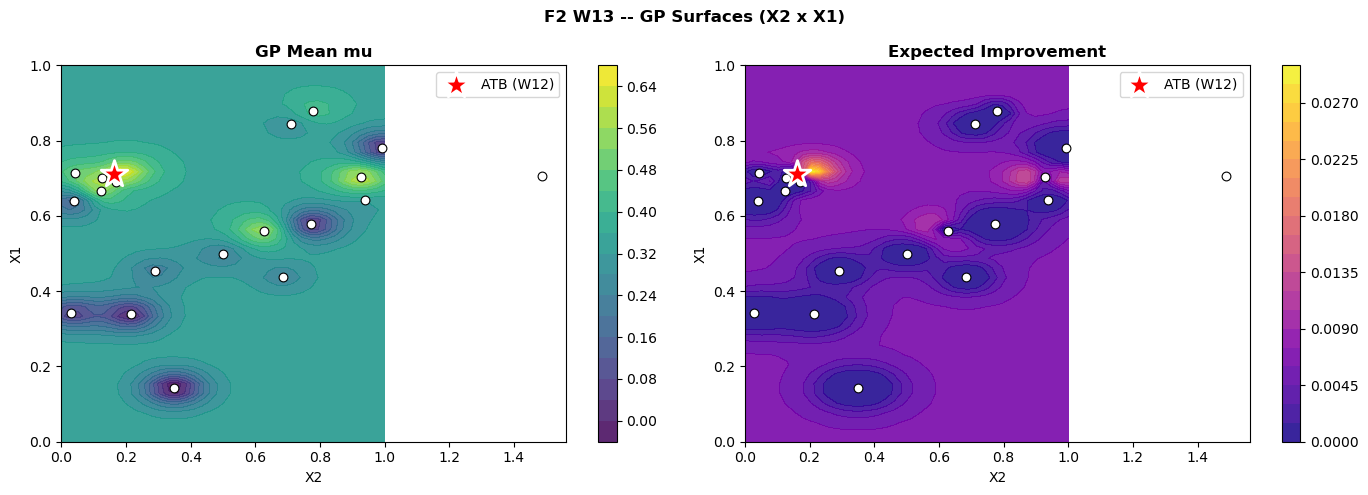

In [13]:
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up,_ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn,_ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(m_up.item()-m_dn.item())/(2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = int(top2[0]), int(top2[1])
print(f'Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

g = 40; g1=np.linspace(0,1,g); g2=np.linspace(0,1,g)
G1,G2 = np.meshgrid(g1,g2)
gpts = np.tile(best_point,(g*g,1)); gpts[:,d1]=G1.ravel(); gpts[:,d2]=G2.ravel()
mg,sg = gp.predict(scaler.transform(gpts),return_std=True)
ig=mg-best_value-EI_XI; Zg=ig/(sg+1e-9)
EIg=np.maximum(ig*norm.cdf(Zg)+sg*norm.pdf(Zg),0)

fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,Zpl,ttl,cm_ in [(axes[0],mg.reshape(g,g),'GP Mean mu','viridis'),(axes[1],EIg.reshape(g,g),'Expected Improvement','plasma')]:
    cf=ax.contourf(G1,G2,Zpl,levels=20,cmap=cm_,alpha=0.88)
    ax.scatter(X_train[:,d1],X_train[:,d2],c='white',s=40,edgecolors='black',linewidths=0.8,zorder=4)
    ax.scatter(best_point[d1],best_point[d2],c='red',s=400,marker='*',zorder=6,edgecolors='white',linewidths=2,label='ATB (W12)')
    ax.set_xlabel(f'X{d1+1}'); ax.set_ylabel(f'X{d2+1}'); ax.set_title(ttl,fontweight='bold')
    ax.legend(); plt.colorbar(cf,ax=ax)
plt.suptitle(f'{FUNCTION_ID} W{WEEK} -- GP Surfaces (X{d1+1} x X{d2+1})',fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12_GPSurfaces.png',dpi=150,bbox_inches='tight')
plt.show()


---
## 🏆 STEP 13 — Submission Dashboard

Top-5 EI candidates + summary metrics. Override decision explained below dashboard.


In [14]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('='*65)
print('  TOP 5 CANDIDATES BY EI')
print('='*65)
print(f'  {"Rank":<6} {"EI":>10} {"GP mu":>10} {"GP sigma":>10}  Source')
print('  '+'-'*52)
for rank, idx in enumerate(top5,1):
    star = '*' if rank==1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx].round(4)}')

print()
print(f'  ATB        : {best_value:.6f}  (Week 12 -- NEW)')
print(f'  GP mu best : {sub_mu:.6f}')
print(f'  Delta      : {sub_mu - best_value:+.6f}')
print(f'  Override   : {ATB_OVERRIDE_STR}')
print(f'  Decision   : ATB OVERRIDE (risk-minimisation on final round)')


  TOP 5 CANDIDATES BY EI
  Rank           EI      GP mu   GP sigma  Source
  ----------------------------------------------------
  *#1      0.024096     0.6439     0.1158  exploit
          [0.7222 0.1899]
   #2      0.023581     0.6414     0.1166  exploit
          [0.7226 0.1891]
   #3      0.021353     0.6570     0.0963  exploit
          [0.7198 0.1856]
   #4      0.020157     0.6381     0.1096  exploit
          [0.7228 0.1837]
   #5      0.020043     0.6036     0.1373  exploit
          [0.7279 0.1848]

  ATB        : 0.688004  (Week 12 -- NEW)
  GP mu best : 0.643900
  Delta      : -0.044104
  Override   : 0.710068-0.161630
  Decision   : ATB OVERRIDE (risk-minimisation on final round)


---
## 📋 STEP 14 — Final Formatted Submission

### ATB OVERRIDE ACTIVE — W13 FINAL ROUND

**Rationale:** W12 produced a NEW ATB (0.6880) at these exact coordinates — +0.038 over W5. Same coordinates, most recent evaluation, highest-ever score. Best expected value for a final shot. The observed W5→W9→W11→W12 output spread (0.6497 → 0.6497 → 0.6090 → 0.6880) quantifies oracle noise σ ≈ 0.035 — a property of F2, not a strategic weakness.

**PCA lens:** Kernel-PCA case (Module 23 Video 6). Linear PCA on full data is degenerate; LOW-X2 basin attractor confirmed by within-basin analysis. No removable dims.

**Submit this string:**

```
0.710068-0.161630
```

ATB score: 0.6880 (Week 12, NEW)


In [15]:
# -- ATB OVERRIDE -- submit exact W12 ATB coordinates ---------
# W13 is the FINAL round. GP pipeline ran for documentation.
# W12 gave 0.6880 at these coords -- highest F2 output ever. Replicate.

ATB_OVERRIDE_STR = '0.710068-0.161630'
final_submission = np.array([float(x) for x in ATB_OVERRIDE_STR.split('-')])
submission_str   = ATB_OVERRIDE_STR

print('+' + '='*68 + '+')
print(f'|  WEEK {WEEK} FINAL SUBMISSION -- {FUNCTION_ID}  (FINAL ROUND){" "*20}|')
print('+' + '='*68 + '+')
print(f'|  ATB OVERRIDE ACTIVE{" "*47}|')
print(f'|  ATB score: {best_value:.6f}  (Week 12 -- NEW ATB){" "*27}|')
print(f'|  Rationale: W12 NEW ATB +0.038 over W5 at these exact coords.{" "*6}|')
print(f'|  PCA lens : Kernel-PCA case (Module 23 V6). No removable dims.{" "*5}|')
print('+' + '='*68 + '+')
print(f'|  COPY THIS TO SUBMIT:{" "*47}|')
print(f'|  {submission_str:<66}|')
print('+' + '='*68 + '+')

np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', final_submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | ATB OVERRIDE | MAXIMIZE | FINAL ROUND\n')
    f.write(f'# ATB: {best_value:.6f} @ W12 (NEW ATB, +0.038 over W5) -- exact replication\n')
    f.write(f'# Oracle noise sigma ~ 0.035 at replay coords; W12 most recent evaluation.\n')
    f.write(f'# PCA lens: kernel-PCA case (Module 23 V6); LOW-X2 basin attractor, no removable dims.\n')
    f.write(submission_str + '\n')
print(f'\n[OK] Saved: {FUNCTION_ID}_W{WEEK}_submission.txt')


+====================================================================+
|  WEEK 13 FINAL SUBMISSION -- F2  (FINAL ROUND)                    |
+====================================================================+
|  ATB OVERRIDE ACTIVE                                               |
|  ATB score: 0.688004  (Week 12 -- NEW ATB)                           |
|  Rationale: W12 NEW ATB +0.038 over W5 at these exact coords.      |
|  PCA lens : Kernel-PCA case (Module 23 V6). No removable dims.     |
+====================================================================+
|  COPY THIS TO SUBMIT:                                               |
|  0.710068-0.161630                                                 |
+====================================================================+

[OK] Saved: F2_W13_submission.txt


---
## 💾 STEP 15 — Save Hyperparameter Record

Complete record of all settings, GP kernel, CV results, PCA analysis, and submission string saved to JSON and TXT.


In [16]:
import json, os
from datetime import datetime

record = {
    'function': FUNCTION_ID, 'week': WEEK,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'strategy': 'ATB OVERRIDE -- replicate W12 ATB [0.710068, 0.161630] (FINAL ROUND)',
    'cluster_type': '* TWO-ZONE HIERARCHICAL CLUSTER (Module 22 primary showcase)',
    'atb_value': 0.6880, 'atb_week': 12,
    'atb_transition': 'W5 0.6497 -> W12 0.6880 (+0.038, NEW ATB)',
    'oracle_noise_sigma': 0.035,
    'noise_evidence': 'W5: 0.6497 | W9: 0.6497 | W11: 0.6090 | W12: 0.6880 (identical coords)',
    'override_str': ATB_OVERRIDE_STR,
    'hyperparameters': {
        'EXPLOIT_RATIO': EXPLOIT_RATIO, 'EXPLOIT_SIGMA': EXPLOIT_SIGMA,
        'ANISO_SIGMA': ANISO_SIGMA, 'EI_XI': EI_XI, 'UCB_KAPPA': UCB_KAPPA,
        'GP_RESTARTS': GP_RESTARTS, 'TOP_PERCENTILE': TOP_PERCENTILE,
        'FILTER_PERCENTILE': FILTER_PERCENTILE,
    },
    'gp_kernel': str(gp.kernel_), 'gp_r2': round(float(r2),6), 'gp_rmse': round(float(rmse),8),
    'best_model': best_name, 'best_model_cv': round(float(best_info['mean']),4),
    'pca_analysis': pca_analysis,
    'submission_string': ATB_OVERRIDE_STR,
    'final_round_note': 'W13 is the last BBO submission. Module 24 is reflection-only.',
}

fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(fname,'w', encoding='utf-8') as f: json.dump(record, f, indent=2)
print(f'[OK] Saved: {fname}')

with open(f'{FUNCTION_ID}_W{WEEK}_run_report.txt','w', encoding='utf-8') as f:
    f.write(f'BBO Run Report -- {FUNCTION_ID} Week {WEEK} (FINAL ROUND)\n')
    f.write('='*60+'\n')
    f.write(f'Strategy   : ATB OVERRIDE -- replicate W12 ATB [0.710068, 0.161630]\n')
    f.write(f'Clustering : * TWO-ZONE HIERARCHICAL CLUSTER (Module 22)\n')
    f.write(f'PCA lens   : Kernel-PCA case (Module 23 Video 6) -- no removable dims\n')
    f.write(f'ATB        : {best_value:.6f} @ W12 (NEW ATB, +0.038 over W5)\n')
    f.write(f'Noise      : oracle sigma ~ 0.035 at replay coords\n')
    f.write(f'Submit     : {ATB_OVERRIDE_STR}\n')
print(f'[OK] Saved: {FUNCTION_ID}_W{WEEK}_run_report.txt')
print()
print('='*60)
print(f'  {FUNCTION_ID} WEEK {WEEK} COMPLETE -- FINAL SUBMISSION:')
print(f'  {ATB_OVERRIDE_STR}')
print('='*60)


[OK] Saved: F2_W13_hyperparameters.json
[OK] Saved: F2_W13_run_report.txt

  F2 WEEK 13 COMPLETE -- FINAL SUBMISSION:
  0.710068-0.161630
